In [18]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import cns
import cns.data_utils as cdu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)

In [20]:
samples_df, cns_df = cdu.main_load("3MB")

In [21]:
cns_df = cns.group_samples(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC")))

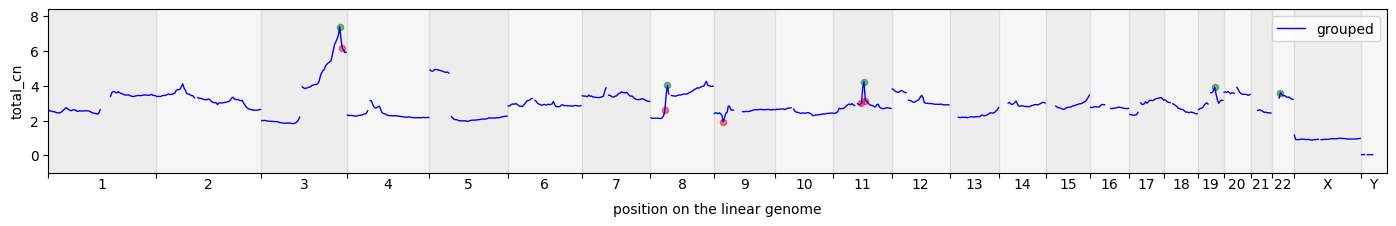

In [29]:
cns_df["score"] = cns.calc_angles(cns_df, "total_cn", 1)

feature = "score"
val_count = 5
sorted_pos = np.argsort(cns_df[feature])
# indices of top 5 values
top_vals = sorted_pos[:val_count]
bot_vals = sorted_pos[-val_count:]

fig, ax = cns.fig_lines( cns_df, cn_columns="total_cn")
cns_df = cns.add_cum_mid(cns_df)
fig.set_size_inches(14, 2)

ax.scatter(cns_df["cum_mid"].iloc[top_vals], cns_df["total_cn"].iloc[top_vals], color='red', alpha=0.5, s=20)
ax.scatter(cns_df["cum_mid"].iloc[bot_vals], cns_df["total_cn"].iloc[bot_vals], color='green', alpha=0.5, s=20)

In [24]:
segs = cdu.load_COSMIC()

In [27]:
scores_df = cns.mean_value_per_seg(cns_df, segs, "score").merge(cns.mean_value_per_seg(cns_df, segs, "total_cn"), on=["chrom", "start", "end", "name"])
scores_df["abs_score"] = scores_df["score"].abs()
scores_df["cum_mid"] = cns.calc_cum_mid(scores_df)
scores_df = scores_df.sort_values("abs_score", ascending=False)
scores_df.head(10)

,chrom,start,end,name,score,total_cn,abs_score,cum_mid
115,chr11,71713909,71791739,NUMA1,67.720495,4.246533,67.720495,1887660714
114,chr11,70049268,70053496,FADD,67.720495,4.246533,67.720495,1885959272
482,chr3,181429713,181432221,SOX2,60.896450,7.400855,60.896450,673880961
621,chr8,38268655,38326352,FGFR1,54.008706,4.026116,54.008706,1431093193
112,chr11,65265232,65273940,MALAT1,-36.888830,2.989666,36.888830,1881177476
111,chr11,64570981,64578766,MEN1,-36.888830,2.989666,36.888830,1880482763
656,chr9,21967750,21995300,CDKN2A,-33.840718,1.928908,33.840718,1561141237
488,chr3,187871071,188608460,LPP,-23.953360,6.161065,23.953360,680689759
487,chr3,187439164,187463515,BCL6,-23.953360,6.161065,23.953360,679901333
486,chr3,186500993,186507689,EIF4A2,-23.953360,6.161065,23.953360,678954335


Text(0.5, 1.0, 'Top 2 genes with highest absolute change score on chr3 in LUSC')

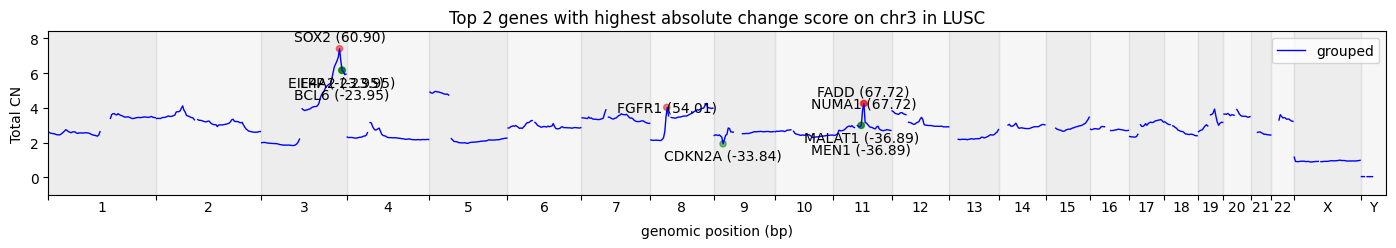

In [53]:
fig, ax = cns.fig_lines(cns_df, cn_columns="total_cn")

# scatter plot of top 5 values in scores_df, use red is score is positive, blue if negative
top_count = 10
top_genes = scores_df.head(top_count)
colors = ["red" if score > 0 else "green" for score in top_genes["score"]]
ax.scatter(top_genes["cum_mid"], top_genes["total_cn"], color=colors, alpha=0.5, s=20)

for i, row in top_genes.iterrows():
	offset = .7 * (-1 if row["score"] > 0 else 1) + (i % 2 * 0.7)
	ax.text(row["cum_mid"], row["total_cn"] - offset, f'{row["name"]} ({row["score"]:.2f})', fontsize=10, ha="center", va="center")


fig.set_size_inches(14, 2)
ax.set_ylabel("Total CN")
ax.set_xlabel("genomic position (bp)")
ax.set_title("Top 2 genes with highest absolute change score on chr3 in LUSC")

In [30]:
ens_segs = cdu.load_ENSEMBL()

In [44]:
ens_cns_df = cns.aggregate_by_segments(cns_df, ens_segs)
ens_cns_df.drop(columns=["total_cn"], inplace=True)
ens_cns_df.head(10)

Aggregated into 20314 CNS.                                        


,sample_id,chrom,start,end,major_cn,minor_cn,name
0,grouped,chr1,69090,70008,1.854562,0.746076,ENSG00000186092
1,grouped,chr1,134900,139379,1.854562,0.746076,ENSG00000237683
2,grouped,chr1,367639,368634,1.854562,0.746076,ENSG00000235249
3,grouped,chr1,621058,622053,1.854562,0.746076,ENSG00000185097
4,grouped,chr1,738531,739137,1.854562,0.746076,ENSG00000269831
5,grouped,chr1,818042,819983,1.854562,0.746076,ENSG00000269308
6,grouped,chr1,860259,879955,1.854562,0.746076,ENSG00000187634
7,grouped,chr1,861263,866445,1.854562,0.746076,ENSG00000268179
8,grouped,chr1,879583,894689,1.854562,0.746076,ENSG00000188976
9,grouped,chr1,895966,901095,1.854562,0.746076,ENSG00000187961


In [47]:
ens_cns_filled_df = cns.main_fill(ens_cns_df)
ens_cns_filled_df.head()

,sample_id,chrom,start,end,major_cn,minor_cn,name
0,grouped,chr1,0,69090,NaN,NaN,NaN
1,grouped,chr1,69090,70008,1.854562,0.746076,ENSG00000186092
2,grouped,chr1,70008,134900,NaN,NaN,NaN
3,grouped,chr1,134900,139379,1.854562,0.746076,ENSG00000237683
4,grouped,chr1,139379,367639,NaN,NaN,NaN


In [49]:
ens_cns_imp_df = cns.main_impute(ens_cns_filled_df)
ens_cns_imp_df.head()

,sample_id,chrom,start,end,major_cn,minor_cn,name
0,grouped,chr1,0,102454,1.854562,0.746076,NaN
1,grouped,chr1,102454,253509,1.854562,0.746076,NaN
2,grouped,chr1,253509,778589,1.854562,0.746076,NaN
3,grouped,chr1,778589,840121,1.854562,0.746076,NaN
4,grouped,chr1,840121,879955,1.854562,0.746076,ENSG00000187634
